EDA Flow

1. Understand the Problem
2. Load the Data
3. Understand the Data
4. Check Data Quality
5. Clean the Data
6. Univariate Analysis
7. Bivariate Analysis
8. Multivariate Analysis
9. Outlier Analysis
10. Feature Engineering
11. Correlation Analysis
12. Final Insights

 Import Libraries

In [1]:
pip install matplotlib seaborn pandas numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid")


2. Load the dataset

In [3]:
df=sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


3. Understand the data

In [4]:
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [5]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [7]:
df.dtypes

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

In [8]:
df.shape

(891, 15)

In [9]:
df.size

13365

In [10]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


4. Check Data Quality

Before analysis, we should check whether the data has problems.

We mainly check:
1. Missing values
2. Duplicate rows
3. Wrong/strange values
4. Data types

4.1 Missing Values

In [11]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Question

What percentage of the data is missing?

In [12]:
(df.isnull().mean() * 100).round(2)

survived        0.00
pclass          0.00
sex             0.00
age            19.87
sibsp           0.00
parch           0.00
fare            0.00
embarked        0.22
class           0.00
who             0.00
adult_male      0.00
deck           77.22
embark_town     0.22
alive           0.00
alone           0.00
dtype: float64

4.2 Visualize Missing Values

Question

Where are the missing values?

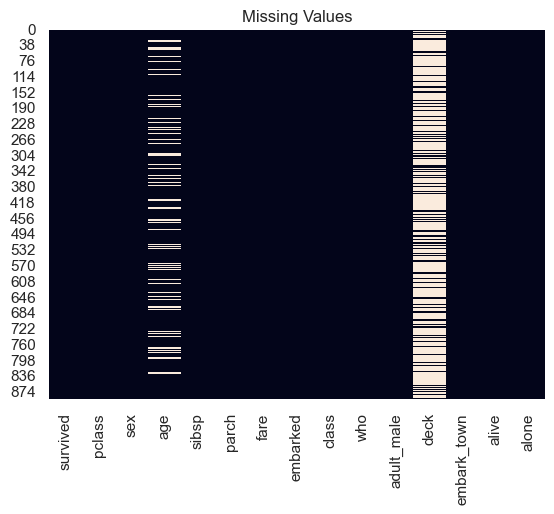

In [13]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

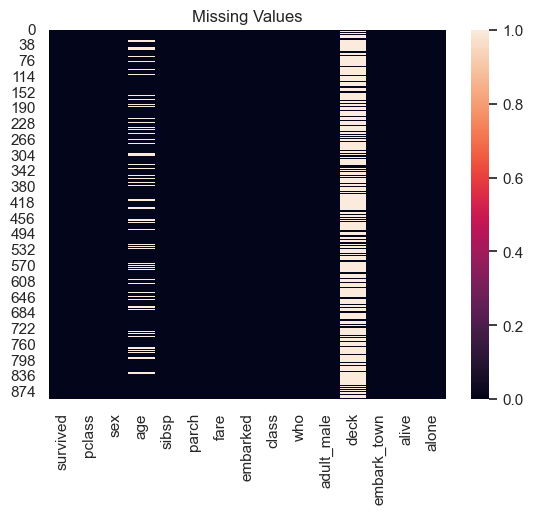

In [14]:
sns.heatmap(df.isnull(), cbar=True)
plt.title("Missing Values")
plt.show()

4.3 Duplicate Rows

Question

Are there duplicate records?

In [15]:
df.duplicated().sum()

np.int64(107)

4.4 Data Types

Question

Which columns are numerical and which are categorical?

In [16]:
display(df.dtypes)

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

5. Clean the Data

Important principle-

Do not blindly delete data. Understand the problem first.

5.1 Handle Missing Age

Question-

What should we do with missing age values?

For this beginner example, we will use the median age.

In [17]:
df["age"]=df["age"].fillna(df["age"].median())
print("Missing age:", df["age"].isnull().sum())

Missing age: 0


5.2 Handle Missing Embarked

Question

What should we do with a very small number of missing categorical values?
For this example, we use the mode.

In [18]:
df["embarked"]=df["embarked"].fillna(df["embarked"].mode()[0])
print("Missing embarked:", df["embarked"].isnull().sum())

Missing embarked: 0


5.3 Handle Deck

Question

What should we do when a categorical column has many missing values?

Instead of guessing the deck, we can label missing values as Unknown.

In [19]:
df["deck"] = df["deck"].astype("object").fillna("Unknown")

print("Missing deck:", df["deck"].isnull().sum())

Missing deck: 0


6. Univariate Analysis




6.1 Survival

Question

How many passengers survived?

In [20]:
df["survived"].value_counts()


survived
0    549
1    342
Name: count, dtype: int64

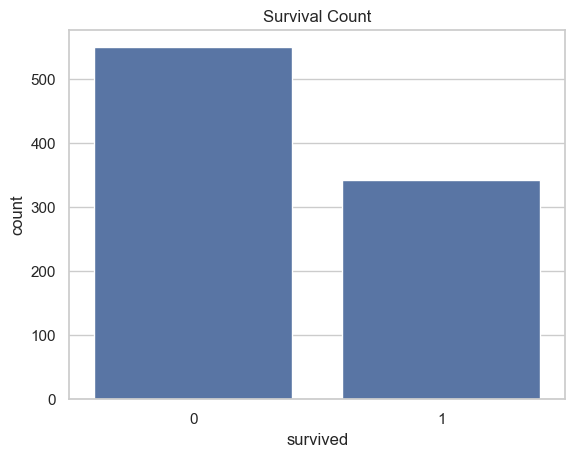

In [21]:
sns.countplot(data=df, x="survived")
plt.title("Survival Count")
plt.show()

6.2 Gender

Question

How many male and female passengers were there?

In [22]:
df["sex"].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

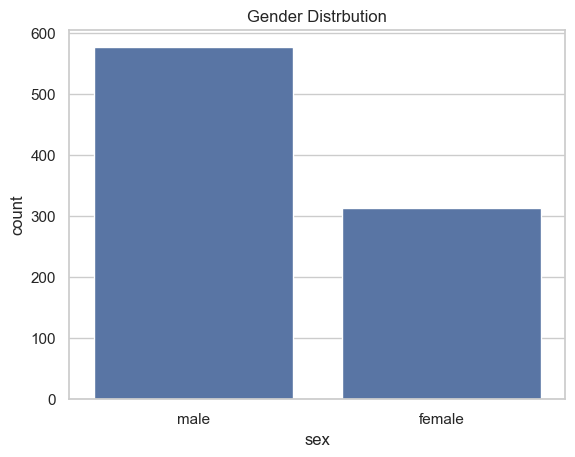

In [26]:
sns.countplot(data=df,x="sex")
plt.title("Gender Distrbution")
plt.show()

6.3 Passenger Class

Question

How many passengers were in each class?

In [27]:
display(df["class"].value_counts())

class
Third     491
First     216
Second    184
Name: count, dtype: int64

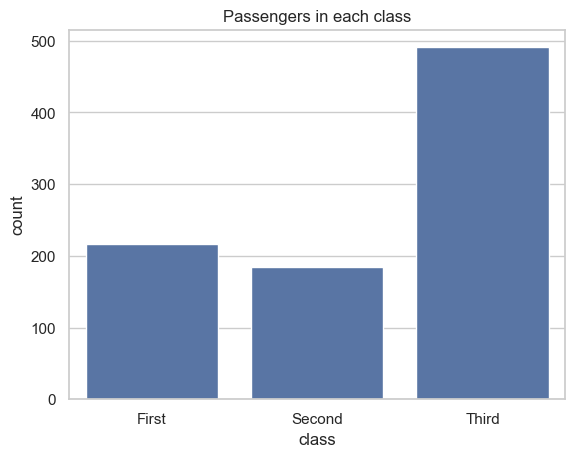

In [29]:
sns.countplot(data=df,x="class",order=["First","Second","Third"])
plt.title("Passengers in each class")
plt.show()

6.4 Age

Question

What does the age distribution look like?

A histogram is useful for numerical data.

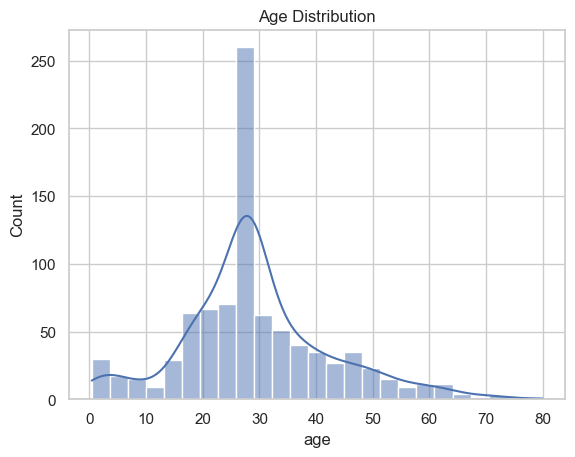

In [34]:
sns.histplot(data=df,x="age",bins=25,kde=True)
plt.title("Age Distribution")
plt.show()

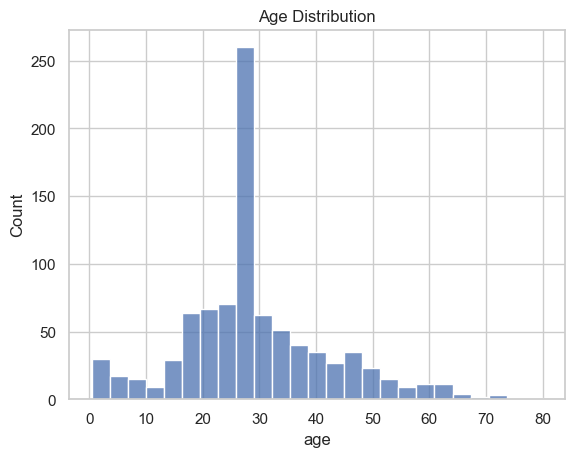

In [39]:
sns.histplot(data=df,x="age",bins=25,kde=False)
plt.title("Age Distribution")
plt.show()

6.5 Fare

Question

How are ticket fares distributed?

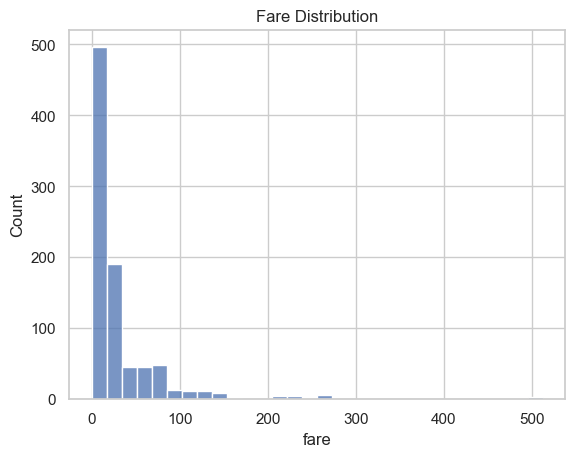

In [36]:
sns.histplot(data=df, x="fare", bins=30, kde=False)
plt.title("Fare Distribution")
plt.show()

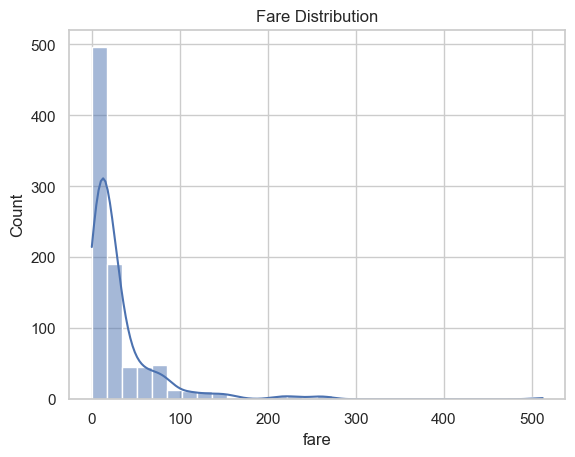

In [38]:
sns.histplot(data=df, x="fare", bins=30, kde=True)
plt.title("Fare Distribution")
plt.show()

7. Bivariate Analysis

Meaning      Bi = Two

Now we analyze two variables together.

Our main question is:     
How is another variable related to survival?

7.1 Gender vs Survival

Question     
Does survival differ between males and females?

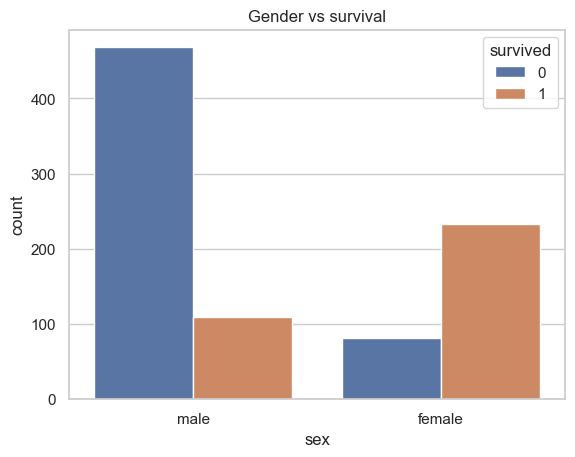

In [42]:
sns.countplot(data=df,x="sex",hue="survived")
plt.title("Gender vs survival")
plt.show()

Question      
What percentage of each gender survived?

In [ ]:
(df.groupby("sex")["survived"].sum())

sex
female   -234
male     -110
Name: survived, dtype: int64

Question   
What percentage of each gender survived?

In [47]:
(df.groupby("sex")["survived"].mean())

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

7.2 Passenger Class vs Survival

Question     
Does passenger class affect survival?

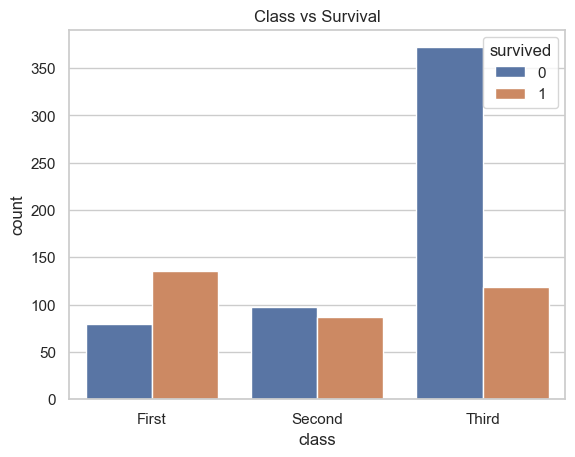

In [48]:
sns.countplot(
    data=df,
    x="class",
    hue="survived",
    order=["First", "Second", "Third"]
)
plt.title("Class vs Survival")
plt.show()

In [49]:
df.groupby("class", observed=True)["survived"].mean()

class
First     0.629630
Second    0.472826
Third     0.242363
Name: survived, dtype: float64

7.3 Age vs Survival

Question      
Is the age distribution different for survivors and non-survivors?

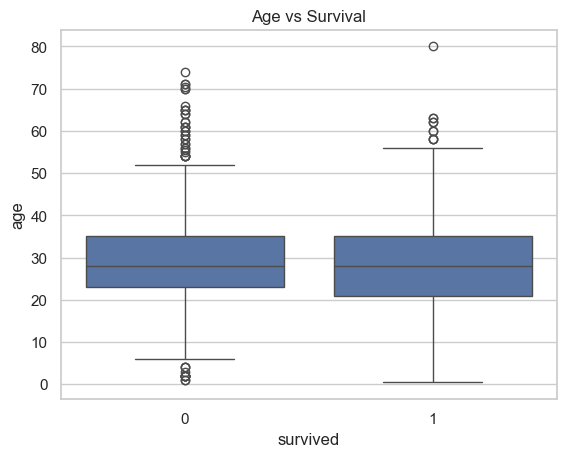

In [50]:
sns.boxplot(data=df, x="survived", y="age")
plt.title("Age vs Survival")
plt.show()

7.4 Fare vs Survival

Question    
Did passengers paying higher fares have different survival rates?

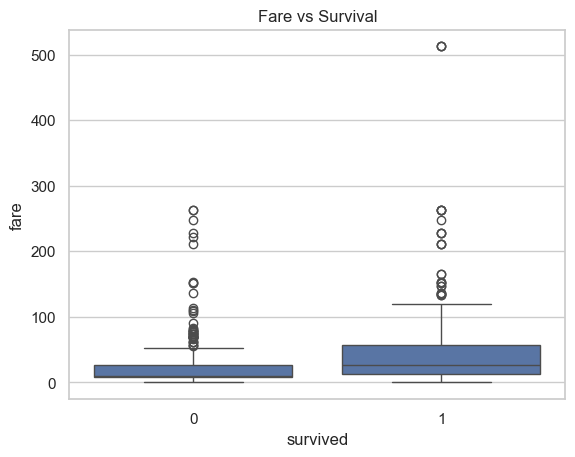

In [51]:
sns.boxplot(data=df, x="survived", y="fare")
plt.title("Fare vs Survival")
plt.show()

7.5 Embarkation vs Survival

Question        
Does survival differ by the passenger's embarkation port?

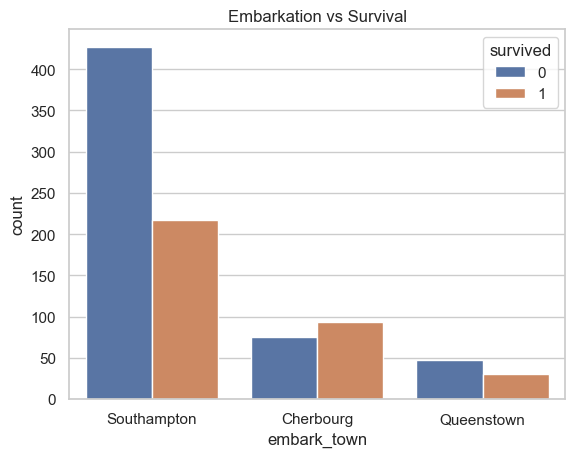

In [52]:
sns.countplot(data=df, x="embark_town", hue="survived")
plt.title("Embarkation vs Survival")
plt.show()

In [53]:
df.groupby("embark_town", observed=True)["survived"].mean()

embark_town
Cherbourg      0.553571
Queenstown     0.389610
Southampton    0.336957
Name: survived, dtype: float64

8. Family Analysis 

Family information is useful because people did not always travel alone.

8.1 Create Family Size      

Question    
Can we create a new feature showing the total family size?

Formula:       
Family Size = SibSp + Parch + 1

In [54]:
df["family_size"] = df["sibsp"] + df["parch"] + 1

df[["sibsp", "parch", "family_size"]].head()

,sibsp,parch,family_size
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


8.2 Family Size vs Survival

Question    
Does family size appear related to survival?

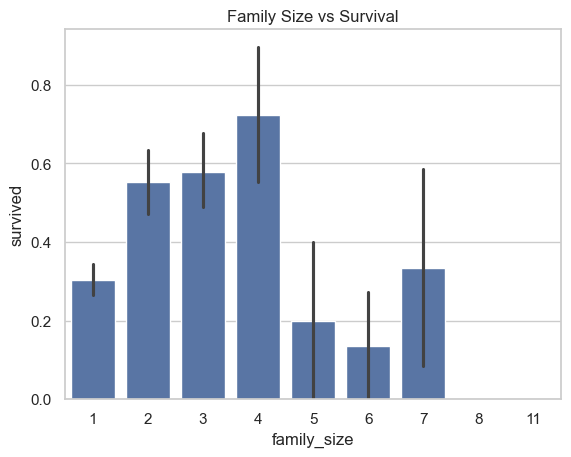

In [55]:
sns.barplot(data=df, x="family_size", y="survived")
plt.title("Family Size vs Survival")
plt.show()

8.3 Travelling Alone vs Survival

Question    
Did passengers travelling alone have a different survival rate?

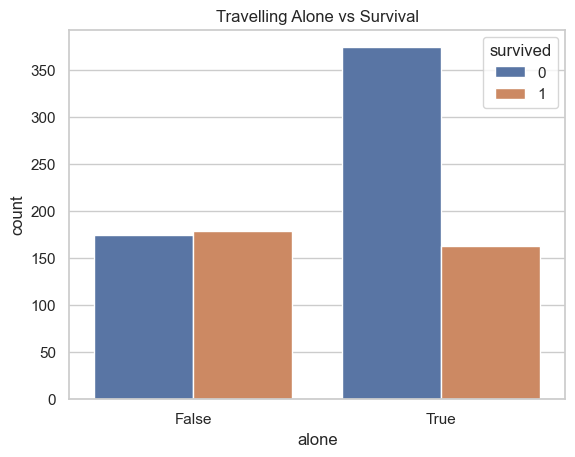

In [56]:
sns.countplot(data=df, x="alone", hue="survived")
plt.title("Travelling Alone vs Survival")
plt.show()

In [57]:
df.groupby("alone")["survived"].mean()

alone
False    0.505650
True     0.303538
Name: survived, dtype: float64

9. Multivariate Analysis

Meaning
Multi = More than two variables

Now we ask questions involving three or more variables.


9.1 Gender + Class + Survival

Cell 72 of 100

9.1 Gender + Class + Survival

Question     
Does survival depend on both gender and passenger class?

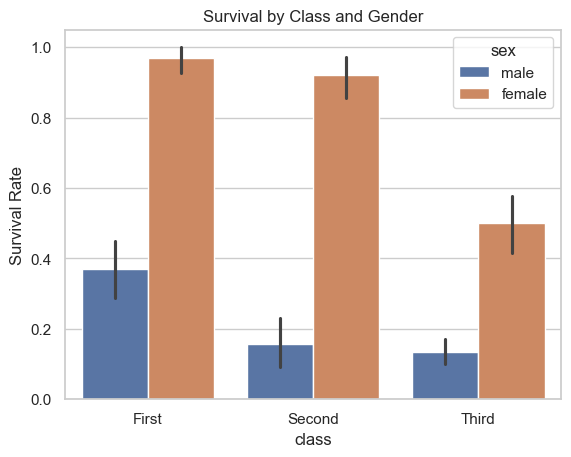

In [58]:
sns.barplot(
    data=df,
    x="class",
    y="survived",
    hue="sex",
    order=["First", "Second", "Third"]
)
plt.title("Survival by Class and Gender")
plt.ylabel("Survival Rate")
plt.show()

9.2 Age + Class + Survival

Question    
How does age differ across passenger classes and survival status

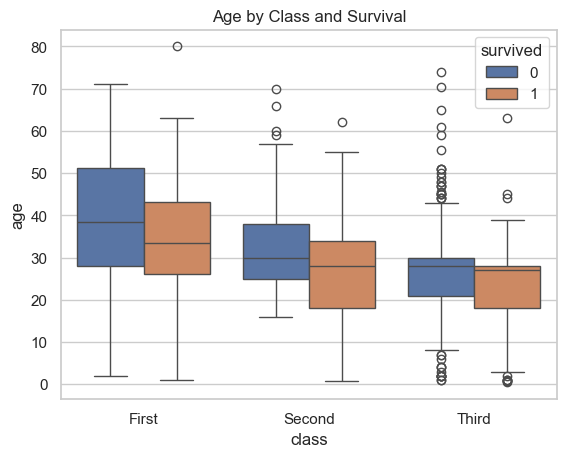

In [59]:
sns.boxplot(
    data=df,
    x="class",
    y="age",
    hue="survived",
    order=["First", "Second", "Third"]
)
plt.title("Age by Class and Survival")
plt.show()

9.3 Age + Fare + Survival

Question
Is there a relationship between age and fare, and does survival differ?

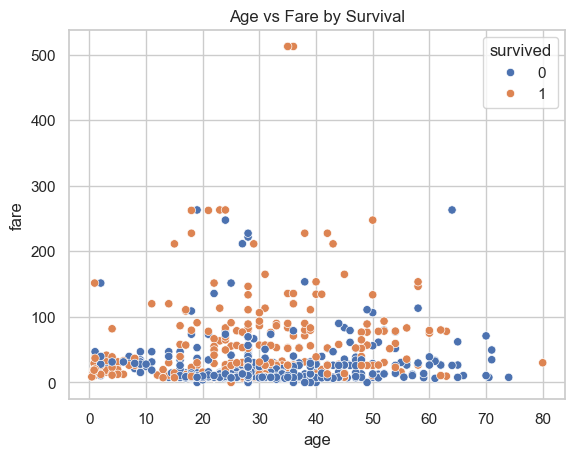

In [60]:
sns.scatterplot(
    data=df,
    x="age",
    y="fare",
    hue="survived"
)
plt.title("Age vs Fare by Survival")
plt.show()

10. Outlier Analysis

Question

Are there unusual values in our numerical columns?
We can start with a box plot.

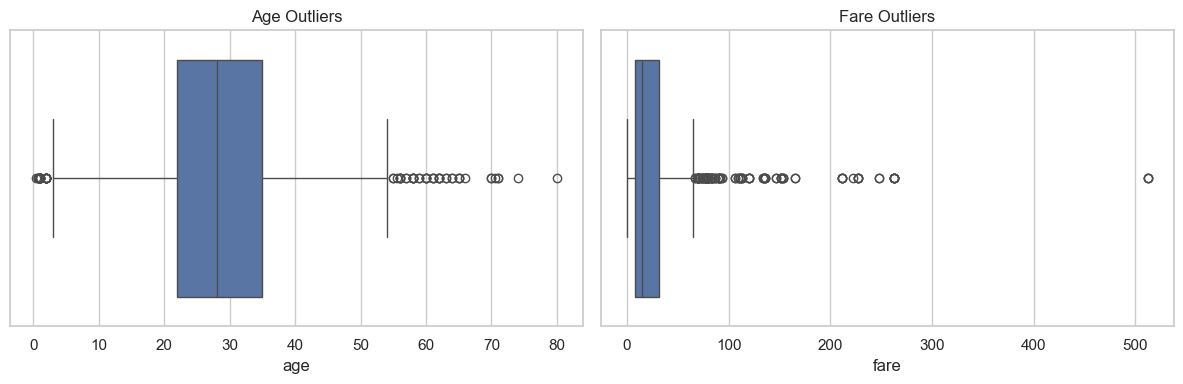

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x="age", ax=axes[0])
axes[0].set_title("Age Outliers")

sns.boxplot(data=df, x="fare", ax=axes[1])
axes[1].set_title("Fare Outliers")

plt.tight_layout()
plt.show()

IQR Method

IQR = Q3 - Q1         
Lower Limit = Q1 - 1.5 × IQR      
Upper Limit = Q3 + 1.5 × IQR

Question     
How can we mathematically identify potential outliers?

In [62]:
Q1 = df["fare"].quantile(0.25)
Q3 = df["fare"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["fare"] < lower) |
    (df["fare"] > upper)
]

print("Number of fare outliers:", len(outliers))
outliers.head()

Number of fare outliers: 116


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2
27,0,1,male,19.0,3,2,263.0000,S,First,man,True,C,Southampton,no,False,6
31,1,1,female,28.0,1,0,146.5208,C,First,woman,False,B,Cherbourg,yes,False,2
34,0,1,male,28.0,1,0,82.1708,C,First,man,True,Unknown,Cherbourg,no,False,2
52,1,1,female,49.0,1,0,76.7292,C,First,woman,False,D,Cherbourg,yes,False,2


Important

Outlier does not automatically mean wrong data.

A high Titanic fare could be a genuine first-class or group ticket.
Always investigate before deleting.

11. Correlation Analysis

Question      
Which numerical variables are related to each other?         
Correlation gives us the strength and direction of a linear relationship.

In [63]:
numeric_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

correlation = df[numeric_columns].corr()

correlation

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307
pclass,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500
age,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688
sibsp,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651
parch,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225
fare,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000


Correlation Heatmap

+1  → Strong positive relationship           
 0  → Little/no linear relationship           
-1  → Strong negative relationship

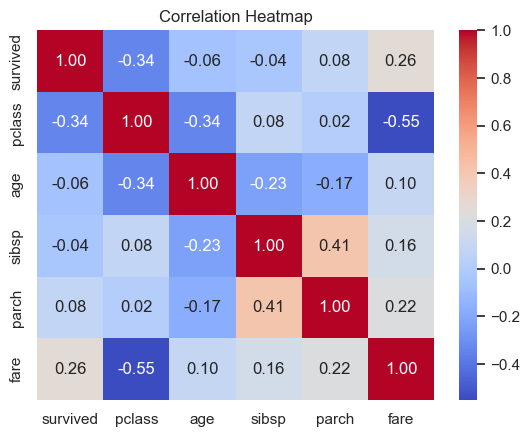

In [64]:
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

 12. Simple Group Analysis

Question

What is the survival rate for each gender and class combination?          
This is a very useful way to summarize our findings.

In [65]:
    df.groupby(
    ["sex", "class"],
    observed=True
)["survived"].mean()

sex     class 
female  First     0.968085
        Second    0.921053
        Third     0.500000
male    First     0.368852
        Second    0.157407
        Third     0.135447
Name: survived, dtype: float64

13. Pivot Table

Question

Can we see the same survival rates in a simple table?

In [66]:
pd.pivot_table(
    df,
    values="survived",
    index="sex",
    columns="class",
    aggfunc="mean"
)

C:\Users\jagat\AppData\Local\Temp\ipykernel_37496\3477933537.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(


class,First,Second,Third
sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447
